# Face Analysis Pipeline - Phase 5
## Emotion Classification (Child Faces Only)

**Input:** Child face crops from Phase 4
**Output:** Emotion labels (Happy/Sad/Neutral) + Confusion Matrix
**Model:** DeepFace (pretrained)

## Step 1: Install Dependencies

In [2]:
!pip install deepface scikit-learn seaborn -q
print("✓ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00
✓ Dependencies installed


## Step 2: Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


## Step 3: Imports

In [4]:
import cv2
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from deepface import DeepFace
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

25-12-27 20:20:32 - Directory /root/.deepface has been created
25-12-27 20:20:32 - Directory /root/.deepface/weights has been created
✓ Libraries imported


## Step 4: Configuration

In [5]:
BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
CHILD_FOLDER = BASE_PATH / "classified/child"
EMOTION_FOLDER = BASE_PATH / "emotions"
HAPPY_FOLDER = EMOTION_FOLDER / "happy"
SAD_FOLDER = EMOTION_FOLDER / "sad"
NEUTRAL_FOLDER = EMOTION_FOLDER / "neutral"
METRICS_FOLDER = BASE_PATH / "metrics"
GROUND_TRUTH_FOLDER = BASE_PATH / "ground_truth"
CHECKPOINT_FILE = BASE_PATH / "checkpoint_emotion.json"

# Map DeepFace emotions to our 3 categories
EMOTION_MAPPING = {
    'happy': 'happy',
    'sad': 'sad',
    'neutral': 'neutral',
    'angry': 'sad',       # Map angry to sad
    'fear': 'sad',        # Map fear to sad
    'disgust': 'sad',     # Map disgust to sad
    'surprise': 'happy'   # Map surprise to happy
}

# Create folders
HAPPY_FOLDER.mkdir(exist_ok=True, parents=True)
SAD_FOLDER.mkdir(exist_ok=True, parents=True)
NEUTRAL_FOLDER.mkdir(exist_ok=True, parents=True)

print(f"Input (child faces): {CHILD_FOLDER}")
print(f"Output: {EMOTION_FOLDER}")

Input (child faces): /content/drive/MyDrive/face_pipeline_project/classified/child
Output: /content/drive/MyDrive/face_pipeline_project/emotions


## Step 5: Checkpoint Functions

In [6]:
def load_checkpoint():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, 'r') as f:
            cp = json.load(f)
            print(f"✓ Loaded: {len(cp.get('completed_videos', []))} videos done")
            return cp
    return {'completed_videos': [], 'happy': 0, 'sad': 0, 'neutral': 0, 'failed': 0}

def save_checkpoint(cp):
    cp['last_updated'] = datetime.now().isoformat()
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(cp, f, indent=2)

checkpoint = load_checkpoint()

✓ Loaded: 31 videos done


## Step 6: Count Child Faces

In [7]:
# Get all child face folders
video_folders = sorted([f for f in CHILD_FOLDER.iterdir() if f.is_dir()])
completed = set(checkpoint['completed_videos'])
remaining = [v for v in video_folders if v.name not in completed]

total_faces = sum(len(list(f.glob("*.jpg"))) for f in video_folders)

print(f"Total child faces: {total_faces}")
print(f"Videos: {len(video_folders)} | Completed: {len(completed)} | Remaining: {len(remaining)}")

Total child faces: 6726
Videos: 31 | Completed: 31 | Remaining: 0


## Step 7: Process Child Faces - Emotion Classification

In [8]:
# Load existing classifications
classifications_file = METRICS_FOLDER / "emotion_classifications.csv"
if classifications_file.exists():
    all_classifications = pd.read_csv(classifications_file).to_dict('records')
else:
    all_classifications = []

for video_folder in remaining:
    video_name = video_folder.name
    print(f"\n{'='*50}")
    print(f"Processing: {video_name}")
    print(f"{'='*50}")

    # Create output folders
    (HAPPY_FOLDER / video_name).mkdir(exist_ok=True)
    (SAD_FOLDER / video_name).mkdir(exist_ok=True)
    (NEUTRAL_FOLDER / video_name).mkdir(exist_ok=True)

    face_files = sorted(list(video_folder.glob("*.jpg")))
    print(f"Faces: {len(face_files)}")

    happy_count = 0
    sad_count = 0
    neutral_count = 0
    failed_count = 0

    for face_path in tqdm(face_files, desc="Classifying emotions"):
        try:
            # Analyze emotion with DeepFace
            result = DeepFace.analyze(
                str(face_path),
                actions=['emotion'],
                enforce_detection=False,
                silent=True
            )

            # Get dominant emotion
            if isinstance(result, list):
                emotions = result[0]['emotion']
                dominant = result[0]['dominant_emotion']
            else:
                emotions = result['emotion']
                dominant = result['dominant_emotion']

            # Map to our 3 categories
            mapped_emotion = EMOTION_MAPPING.get(dominant, 'neutral')

            # Determine destination
            if mapped_emotion == 'happy':
                dest_folder = HAPPY_FOLDER / video_name
                happy_count += 1
            elif mapped_emotion == 'sad':
                dest_folder = SAD_FOLDER / video_name
                sad_count += 1
            else:
                dest_folder = NEUTRAL_FOLDER / video_name
                neutral_count += 1

            # Copy file
            shutil.copy(face_path, dest_folder / face_path.name)

            # Log
            all_classifications.append({
                'video': video_name,
                'face_file': face_path.name,
                'deepface_emotion': dominant,
                'mapped_emotion': mapped_emotion,
                'happy_score': round(emotions.get('happy', 0), 2),
                'sad_score': round(emotions.get('sad', 0), 2),
                'neutral_score': round(emotions.get('neutral', 0), 2)
            })

        except Exception as e:
            failed_count += 1
            continue

    # Update checkpoint
    checkpoint['completed_videos'].append(video_name)
    checkpoint['happy'] += happy_count
    checkpoint['sad'] += sad_count
    checkpoint['neutral'] += neutral_count
    checkpoint['failed'] += failed_count
    save_checkpoint(checkpoint)

    print(f"✓ Happy: {happy_count} | Sad: {sad_count} | Neutral: {neutral_count} | Failed: {failed_count}")

    # Save after each video
    pd.DataFrame(all_classifications).to_csv(classifications_file, index=False)

print(f"\n✅ COMPLETE!")
print(f"Happy: {checkpoint['happy']}")
print(f"Sad: {checkpoint['sad']}")
print(f"Neutral: {checkpoint['neutral']}")
print(f"Failed: {checkpoint['failed']}")


✅ COMPLETE!
Happy: 1098
Sad: 4390
Neutral: 1238
Failed: 0


## Step 8: View Emotion Distribution

Total classified: 6726

Emotion distribution:
mapped_emotion
sad        4390
neutral    1238
happy      1098
Name: count, dtype: int64


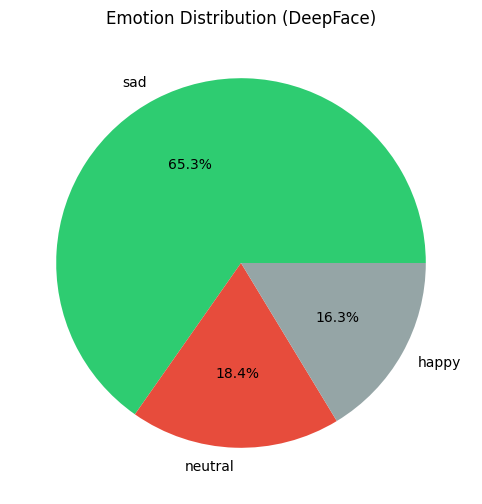

In [9]:
df = pd.read_csv(METRICS_FOLDER / "emotion_classifications.csv")

print(f"Total classified: {len(df)}")
print(f"\nEmotion distribution:")
print(df['mapped_emotion'].value_counts())

# Pie chart
plt.figure(figsize=(8, 6))
df['mapped_emotion'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#95a5a6'])
plt.title('Emotion Distribution (DeepFace)')
plt.ylabel('')
plt.savefig(METRICS_FOLDER / "emotion_distribution.png", dpi=150)
plt.show()

---
# 📊 VALIDATION

## Step 9: Interactive Labeling Tool

In [10]:
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets

df_class = pd.read_csv(METRICS_FOLDER / "emotion_classifications.csv")

# Sample for labeling
SAMPLE_SIZE = 150
df_sample = df_class.sample(n=min(SAMPLE_SIZE, len(df_class)), random_state=42).reset_index(drop=True)

print(f"Total: {len(df_class)} | Sample: {len(df_sample)}")

# Labels storage
LABELS_FILE = GROUND_TRUTH_FOLDER / "emotion_labels_manual.csv"
labels = {}
current_idx = [0]

def save_labels():
    df_sample['actual_emotion'] = df_sample.index.map(lambda x: labels.get(x, ''))
    df_sample.to_csv(LABELS_FILE, index=False)
    return len([v for v in labels.values() if v != ''])

def show_face(idx):
    clear_output(wait=True)

    if idx >= len(df_sample):
        total = save_labels()
        print("✅ DONE!")
        print(f"Labeled: {total}")
        return

    row = df_sample.iloc[idx]
    img_path = CHILD_FOLDER / row['video'] / row['face_file']

    labeled_count = len([v for v in labels.values() if v != ''])

    print(f"Image {idx + 1}/{len(df_sample)}  |  Labeled: {labeled_count}")
    print(f"DeepFace says: {row['mapped_emotion'].upper()}")
    print(f"  Happy: {row['happy_score']}% | Sad: {row['sad_score']}% | Neutral: {row['neutral_score']}%")

    if img_path.exists():
        display(IPImage(filename=str(img_path)))
    else:
        print(f"❌ Not found: {img_path}")

    btn_happy = widgets.Button(description="😊 HAPPY", button_style='success', layout=widgets.Layout(width='150px', height='50px'))
    btn_sad = widgets.Button(description="😢 SAD", button_style='danger', layout=widgets.Layout(width='150px', height='50px'))
    btn_neutral = widgets.Button(description="😐 NEUTRAL", button_style='warning', layout=widgets.Layout(width='150px', height='50px'))
    btn_skip = widgets.Button(description="Skip", layout=widgets.Layout(width='100px'))
    btn_back = widgets.Button(description="← Back", layout=widgets.Layout(width='100px'))
    btn_save = widgets.Button(description="💾 Save", button_style='info', layout=widgets.Layout(width='100px'))

    def on_happy(b):
        labels[idx] = 'happy'
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_sad(b):
        labels[idx] = 'sad'
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_neutral(b):
        labels[idx] = 'neutral'
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_skip(b):
        current_idx[0] += 1
        show_face(current_idx[0])

    def on_back(b):
        if current_idx[0] > 0:
            current_idx[0] -= 1
            show_face(current_idx[0])

    def on_save(b):
        total = save_labels()
        print(f"💾 Saved {total} labels")

    btn_happy.on_click(on_happy)
    btn_sad.on_click(on_sad)
    btn_neutral.on_click(on_neutral)
    btn_skip.on_click(on_skip)
    btn_back.on_click(on_back)
    btn_save.on_click(on_save)

    display(widgets.HBox([btn_happy, btn_sad, btn_neutral]))
    display(widgets.HBox([btn_skip, btn_back, btn_save]))

print("🏁 Starting...")
show_face(0)

✅ DONE!
Labeled: 149


## Step 10: Confusion Matrix

Labeled: 149


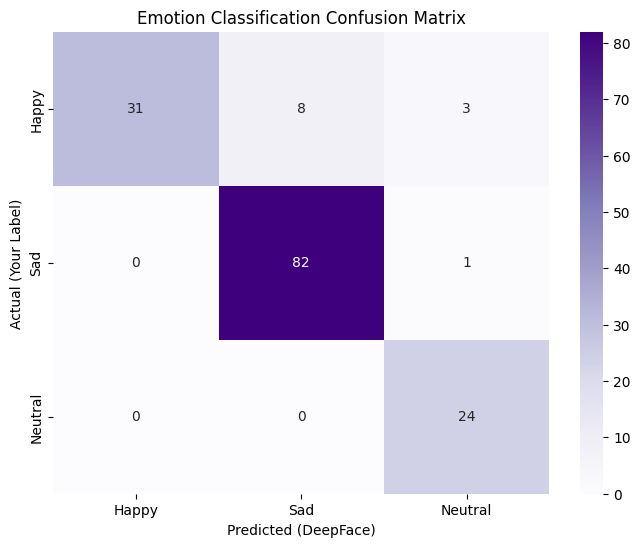


              precision    recall  f1-score   support

       Happy       1.00      0.74      0.85        42
         Sad       0.91      0.99      0.95        83
     Neutral       0.86      1.00      0.92        24

    accuracy                           0.92       149
   macro avg       0.92      0.91      0.91       149
weighted avg       0.93      0.92      0.92       149


Overall Accuracy: 91.9%


In [14]:
LABELS_FILE = GROUND_TRUTH_FOLDER / "emotion_labels_manual.csv"

try:
    df_gt = pd.read_csv(LABELS_FILE)
    df_labeled = df_gt[df_gt['actual_emotion'].notna() & (df_gt['actual_emotion'] != '')].copy()

    if len(df_labeled) == 0:
        print("⚠️ No labels! Run Step 9 first.")
    else:
        print(f"Labeled: {len(df_labeled)}")

        y_true = df_labeled['actual_emotion'].values
        y_pred = df_labeled['mapped_emotion'].values

        labels_order = ['happy', 'sad', 'neutral']
        cm = confusion_matrix(y_true, y_pred, labels=labels_order)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                    xticklabels=['Happy', 'Sad', 'Neutral'],
                    yticklabels=['Happy', 'Sad', 'Neutral'])
        plt.xlabel('Predicted (DeepFace)')
        plt.ylabel('Actual (Your Label)')
        plt.title('Emotion Classification Confusion Matrix')
        plt.savefig(METRICS_FOLDER / "confusion_matrix_emotion.png", dpi=150)
        plt.show()

        print("\n" + "="*50)
        print(classification_report(y_true, y_pred, labels=labels_order, target_names=['Happy', 'Sad', 'Neutral'], zero_division=0))

        # Accuracy
        accuracy = (y_true == y_pred).mean()
        print(f"\nOverall Accuracy: {accuracy:.1%}")


except FileNotFoundError:
    print("⚠️ Run Step 9 first!")

---
## ✅ Phase 5 Complete!

**Outputs:**
- Happy faces: `/emotions/happy/`
- Sad faces: `/emotions/sad/`
- Neutral faces: `/emotions/neutral/`
- Classifications: `/metrics/emotion_classifications.csv`
- Confusion matrix: `/metrics/confusion_matrix_emotion.png`

**Pipeline Complete! 🎉**